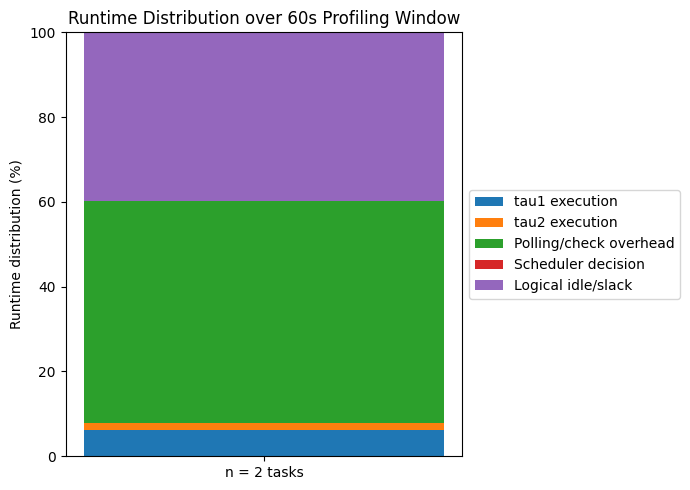

tau1_exec_percent: 6.221613333333333
tau2_exec_percent: 1.7350500000000002
polling_only_percent: 52.2334
scheduler_event_percent: 0.0083
logical_idle_percent: 39.8008
sum: 99.99916333333334


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data from polling-enabled 60s run
profile_window_us = 60_000_000

tau1_runs = 599
tau1_avg_exec_us = 6232

tau2_runs = 30
tau2_avg_exec_us = 34701

polling_check_percent = 52.2417
scheduler_event_percent = 0.0083
logical_idle_percent = 39.8008

# Split task execution into tau1 and tau2
tau1_exec_percent = (tau1_runs * tau1_avg_exec_us) / profile_window_us * 100
tau2_exec_percent = (tau2_runs * tau2_avg_exec_us) / profile_window_us * 100

# Avoid double-counting:
# scheduler_event is already included inside polling_check,
# so subtract it from polling_check before stacking.
polling_only_percent = polling_check_percent - scheduler_event_percent

labels = ["n = 2 tasks"]

components = [
    ("tau1 execution", [tau1_exec_percent]),
    ("tau2 execution", [tau2_exec_percent]),
    ("Polling/check overhead", [polling_only_percent]),
    ("Scheduler decision", [scheduler_event_percent]),
    ("Logical idle/slack", [logical_idle_percent]),
]

bottom = np.zeros(len(labels))

plt.figure(figsize=(7, 5))

for name, values in components:
    plt.bar(labels, values, bottom=bottom, label=name)
    bottom += np.array(values)

plt.ylabel("Runtime distribution (%)")
plt.ylim(0, 100)
plt.title("Runtime Distribution over 60s Profiling Window")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

print("tau1_exec_percent:", tau1_exec_percent)
print("tau2_exec_percent:", tau2_exec_percent)
print("polling_only_percent:", polling_only_percent)
print("scheduler_event_percent:", scheduler_event_percent)
print("logical_idle_percent:", logical_idle_percent)
print("sum:", tau1_exec_percent + tau2_exec_percent + polling_only_percent + scheduler_event_percent + logical_idle_percent)

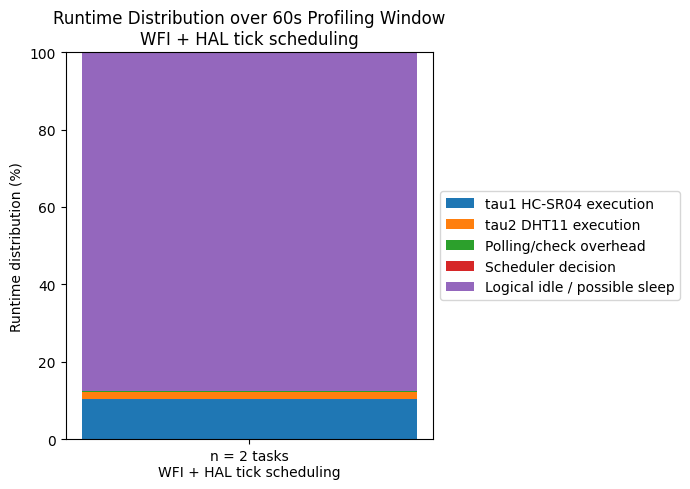

tau1_exec_percent: 10.465
tau2_exec_percent: 1.71275
polling_only_percent: 0.1435
scheduler_event_percent: 0.0017
logical_idle_percent: 87.676
sum: 99.99895000000001


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data from corrected WFI-enabled 60s run
profile_window_us = 60_000_000

tau1_runs = 600
tau1_avg_exec_us = 10465

tau2_runs = 30
tau2_avg_exec_us = 34255

polling_check_percent = 0.1452
scheduler_event_percent = 0.0017
logical_idle_percent = 87.6760

# Split task execution into tau1 and tau2
tau1_exec_percent = (tau1_runs * tau1_avg_exec_us) / profile_window_us * 100
tau2_exec_percent = (tau2_runs * tau2_avg_exec_us) / profile_window_us * 100

# Avoid double-counting:
# scheduler_event is included inside the measured polling/check decision cost,
# so subtract it before stacking.
polling_only_percent = polling_check_percent - scheduler_event_percent

labels = ["n = 2 tasks\nWFI + HAL tick scheduling"]

components = [
    ("tau1 HC-SR04 execution", [tau1_exec_percent]),
    ("tau2 DHT11 execution", [tau2_exec_percent]),
    ("Polling/check overhead", [polling_only_percent]),
    ("Scheduler decision", [scheduler_event_percent]),
    ("Logical idle / possible sleep", [logical_idle_percent]),
]

bottom = np.zeros(len(labels))

plt.figure(figsize=(7, 5))

for name, values in components:
    plt.bar(labels, values, bottom=bottom, label=name)
    bottom += np.array(values)

plt.ylabel("Runtime distribution (%)")
plt.ylim(0, 100)
plt.title("Runtime Distribution over 60s Profiling Window\nWFI + HAL tick scheduling")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

print("tau1_exec_percent:", tau1_exec_percent)
print("tau2_exec_percent:", tau2_exec_percent)
print("polling_only_percent:", polling_only_percent)
print("scheduler_event_percent:", scheduler_event_percent)
print("logical_idle_percent:", logical_idle_percent)
print("sum:", tau1_exec_percent + tau2_exec_percent + polling_only_percent + scheduler_event_percent + logical_idle_percent)

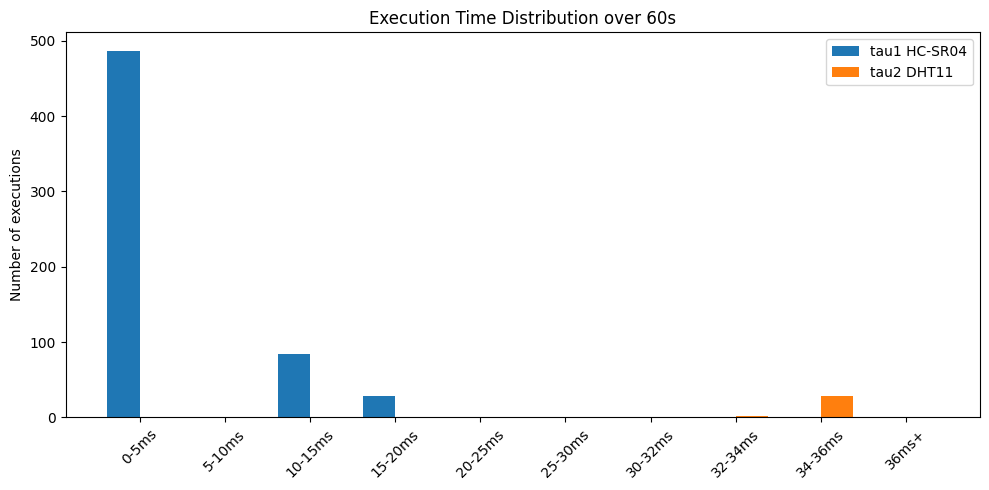

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

bins = [
    "0-5ms", "5-10ms", "10-15ms", "15-20ms", "20-25ms",
    "25-30ms", "30-32ms", "32-34ms", "34-36ms", "36ms+"
]

# Polling-enabled run
tau1_counts = [487, 0, 84, 28, 0, 0, 0, 0, 0, 0]
tau2_counts = [0, 0, 0, 0, 0, 0, 0, 2, 28, 0]

x = np.arange(len(bins))
width = 0.38

plt.figure(figsize=(10, 5))
plt.bar(x - width/2, tau1_counts, width, label="tau1 HC-SR04")
plt.bar(x + width/2, tau2_counts, width, label="tau2 DHT11")

plt.xticks(x, bins, rotation=45)
plt.ylabel("Number of executions")
plt.title("Execution Time Distribution over 60s")
plt.legend()
plt.tight_layout()
plt.show()

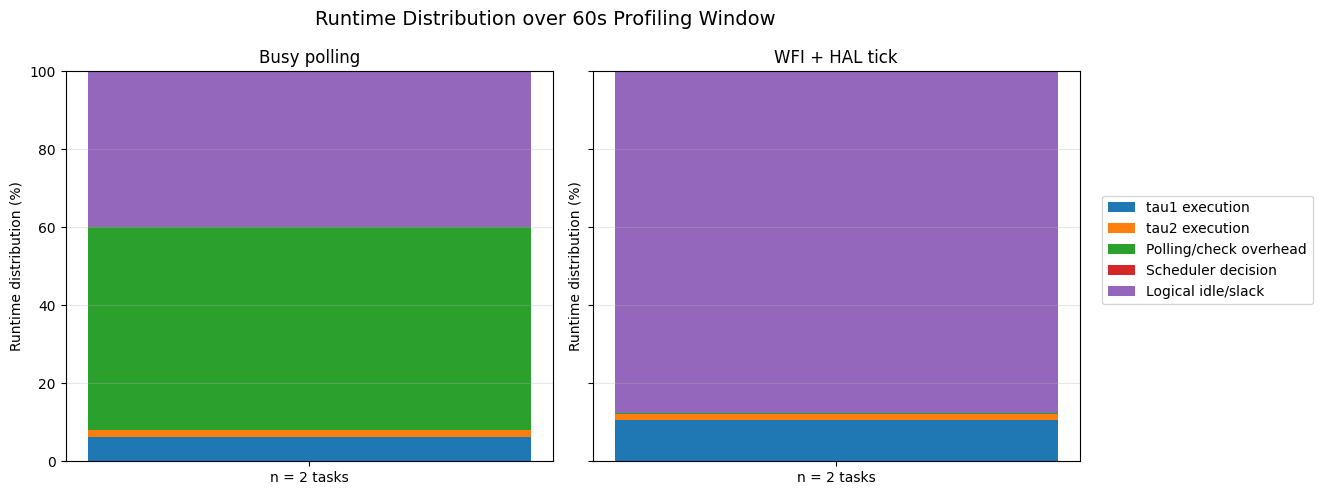


=== Busy polling ===
tau1 execution: 6.2216%
tau2 execution: 1.7351%
Polling/check overhead: 52.2334%
Scheduler decision: 0.0083%
Logical idle/slack: 39.8008%
sum: 99.9992%

=== WFI + HAL tick ===
tau1 execution: 10.4650%
tau2 execution: 1.7127%
Polling/check overhead: 0.1435%
Scheduler decision: 0.0017%
Logical idle/slack: 87.6760%
sum: 99.9990%


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

profile_window_us = 60_000_000

runs = {
    "Busy polling": {
        "tau1_runs": 599,
        "tau1_avg_exec_us": 6232,
        "tau2_runs": 30,
        "tau2_avg_exec_us": 34701,
        "polling_check_percent": 52.2417,
        "scheduler_event_percent": 0.0083,
        "logical_idle_percent": 39.8008,
        "idle_label": "Logical idle/slack",
    },
    "WFI + HAL tick": {
        "tau1_runs": 600,
        "tau1_avg_exec_us": 10465,
        "tau2_runs": 30,
        "tau2_avg_exec_us": 34255,
        "polling_check_percent": 0.1452,
        "scheduler_event_percent": 0.0017,
        "logical_idle_percent": 87.6760,
        "idle_label": "Logical idle / possible sleep",
    }
}

# Same component order for both plots
component_names = [
    "tau1 execution",
    "tau2 execution",
    "Polling/check overhead",
    "Scheduler decision",
    "Logical idle/slack",
]

calculated = {}

for run_name, data in runs.items():
    tau1_exec_percent = (
        data["tau1_runs"] * data["tau1_avg_exec_us"]
    ) / profile_window_us * 100

    tau2_exec_percent = (
        data["tau2_runs"] * data["tau2_avg_exec_us"]
    ) / profile_window_us * 100

    # Avoid double-counting:
    # scheduler_event is already included inside polling_check
    polling_only_percent = (
        data["polling_check_percent"] - data["scheduler_event_percent"]
    )

    calculated[run_name] = {
        "tau1 execution": tau1_exec_percent,
        "tau2 execution": tau2_exec_percent,
        "Polling/check overhead": polling_only_percent,
        "Scheduler decision": data["scheduler_event_percent"],
        "Logical idle/slack": data["logical_idle_percent"],
    }

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

for ax, (run_name, values_dict) in zip(axes, calculated.items()):
    bottom = 0

    for component in component_names:
        value = values_dict[component]
        ax.bar(
            ["n = 2 tasks"],
            [value],
            bottom=bottom,
            label=component
        )
        bottom += value

    ax.set_title(run_name)
    ax.set_ylim(0, 100)
    ax.set_ylabel("Runtime distribution (%)")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Runtime Distribution over 60s Profiling Window", fontsize=14)

# One shared legend for both plots
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.0, 0.5)
)

plt.tight_layout()
plt.show()

# -----------------------------
# Print calculated values
# -----------------------------
for run_name, values in calculated.items():
    print(f"\n=== {run_name} ===")
    total = 0

    for component, value in values.items():
        print(f"{component}: {value:.4f}%")
        total += value

    print(f"sum: {total:.4f}%")

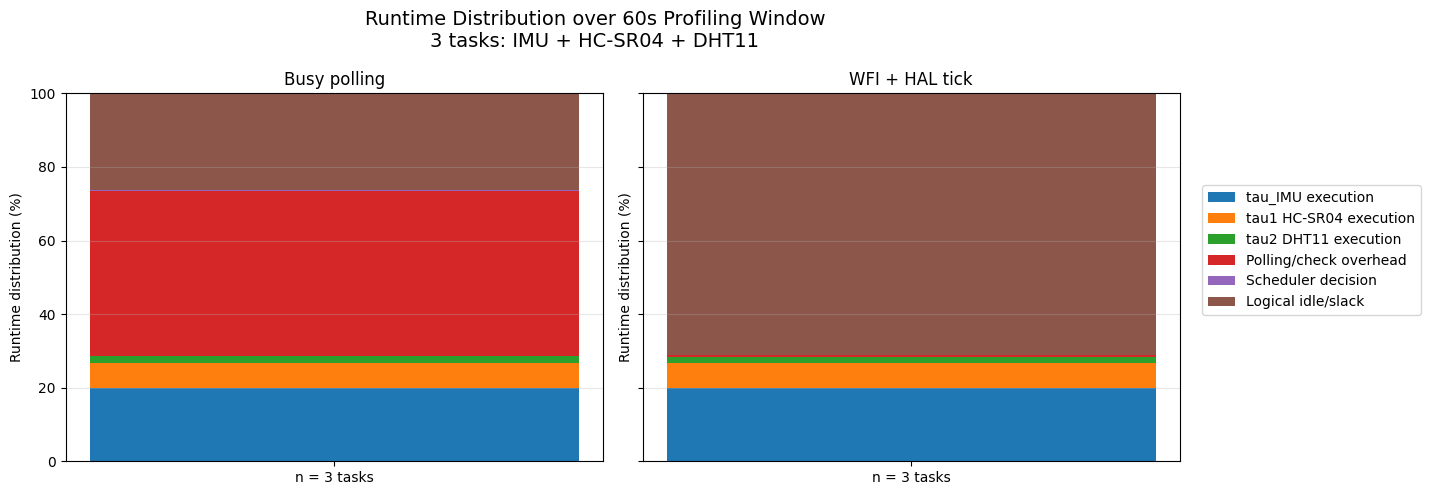


=== Busy polling: runtime distribution ===
tau_IMU execution: 19.8600%
tau1 HC-SR04 execution: 6.8935%
tau2 DHT11 execution: 1.7277%
Polling/check overhead: 45.0676%
Scheduler decision: 0.2667%
Logical idle/slack: 26.1774%
sum: 99.9929%

=== WFI + HAL tick: runtime distribution ===
tau_IMU execution: 19.8583%
tau1 HC-SR04 execution: 6.9000%
tau2 DHT11 execution: 1.6987%
Polling/check overhead: 0.3352%
Scheduler decision: 0.1240%
Logical idle/slack: 71.0721%
sum: 99.9882%

=== Busy polling: deadline / timing quality ===
tau_IMU execution: runs=11798, misses=31, skipped=202, total_failures=233, avg_response=1266 us, max_response=39035 us
tau1 HC-SR04 execution: runs=599, misses=0, skipped=0, total_failures=0, avg_response=8143 us, max_response=43970 us
tau2 DHT11 execution: runs=30, misses=0, skipped=0, total_failures=0, avg_response=41609 us, max_response=42980 us
TOTAL: misses=31, skipped=202, total_failures=233

=== WFI + HAL tick: deadline / timing quality ===
tau_IMU execution: run

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

profile_window_us = 60_000_000

# -----------------------------
# Data: 3-task run
# Order: IMU -> tau1 HC-SR04 -> tau2 DHT11
# -----------------------------
runs = {
    "Busy polling": {
        "tasks": {
            "tau_IMU execution": {
                "runs": 11798,
                "avg_exec_us": 1010,
                "misses": 31,
                "skipped": 202,
                "total_failures": 233,
                "avg_response_us": 1266,
                "max_response_us": 39035,
            },
            "tau1 HC-SR04 execution": {
                "runs": 599,
                "avg_exec_us": 6905,
                "misses": 0,
                "skipped": 0,
                "total_failures": 0,
                "avg_response_us": 8143,
                "max_response_us": 43970,
            },
            "tau2 DHT11 execution": {
                "runs": 30,
                "avg_exec_us": 34554,
                "misses": 0,
                "skipped": 0,
                "total_failures": 0,
                "avg_response_us": 41609,
                "max_response_us": 42980,
            },
        },

        "polling_check_percent": 45.3343,
        "scheduler_event_percent": 0.2667,
        "logical_idle_percent": 26.1774,
    },

    "WFI + HAL tick": {
        "tasks": {
            "tau_IMU execution": {
                "runs": 11797,
                "avg_exec_us": 1010,
                "misses": 29,
                "skipped": 203,
                "total_failures": 232,
                "avg_response_us": 1235,
                "max_response_us": 39000,
            },
            "tau1 HC-SR04 execution": {
                "runs": 600,
                "avg_exec_us": 6900,
                "misses": 0,
                "skipped": 0,
                "total_failures": 0,
                "avg_response_us": 7000,
                "max_response_us": 7000,
            },
            "tau2 DHT11 execution": {
                "runs": 30,
                "avg_exec_us": 33973,
                "misses": 0,
                "skipped": 0,
                "total_failures": 0,
                "avg_response_us": 41033,
                "max_response_us": 42000,
            },
        },

        "polling_check_percent": 0.4592,
        "scheduler_event_percent": 0.1240,
        "logical_idle_percent": 71.0721,
    },
}

component_names = [
    "tau_IMU execution",
    "tau1 HC-SR04 execution",
    "tau2 DHT11 execution",
    "Polling/check overhead",
    "Scheduler decision",
    "Logical idle/slack",
]

# -----------------------------
# Prepare calculated data
# -----------------------------
calculated = {}

for run_name, data in runs.items():
    values = {}

    for task_name, task_data in data["tasks"].items():
        values[task_name] = (
            task_data["runs"] * task_data["avg_exec_us"]
        ) / profile_window_us * 100

    # Avoid double-counting:
    # scheduler_event is already included inside polling_check.
    polling_only_percent = (
        data["polling_check_percent"] - data["scheduler_event_percent"]
    )

    values["Polling/check overhead"] = polling_only_percent
    values["Scheduler decision"] = data["scheduler_event_percent"]
    values["Logical idle/slack"] = data["logical_idle_percent"]

    calculated[run_name] = values

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, (run_name, values_dict) in zip(axes, calculated.items()):
    bottom = 0

    for component in component_names:
        value = values_dict[component]

        ax.bar(
            ["n = 3 tasks"],
            [value],
            bottom=bottom,
            label=component
        )

        bottom += value

    ax.set_title(run_name)
    ax.set_ylim(0, 100)
    ax.set_ylabel("Runtime distribution (%)")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(
    "Runtime Distribution over 60s Profiling Window\n"
    "3 tasks: IMU + HC-SR04 + DHT11",
    fontsize=14
)

# One shared legend for both plots
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.0, 0.5)
)

plt.tight_layout()
plt.show()

# -----------------------------
# Print calculated runtime values
# -----------------------------
for run_name, values in calculated.items():
    print(f"\n=== {run_name}: runtime distribution ===")
    total = 0

    for component, value in values.items():
        print(f"{component}: {value:.4f}%")
        total += value

    print(f"sum: {total:.4f}%")

# -----------------------------
# Print timing quality summary
# -----------------------------
for run_name, data in runs.items():
    print(f"\n=== {run_name}: deadline / timing quality ===")

    total_misses = 0
    total_skipped = 0
    total_failures = 0

    for task_name, task_data in data["tasks"].items():
        print(
            f"{task_name}: "
            f"runs={task_data['runs']}, "
            f"misses={task_data['misses']}, "
            f"skipped={task_data['skipped']}, "
            f"total_failures={task_data['total_failures']}, "
            f"avg_response={task_data['avg_response_us']} us, "
            f"max_response={task_data['max_response_us']} us"
        )

        total_misses += task_data["misses"]
        total_skipped += task_data["skipped"]
        total_failures += task_data["total_failures"]

    print(
        f"TOTAL: "
        f"misses={total_misses}, "
        f"skipped={total_skipped}, "
        f"total_failures={total_failures}"
    )

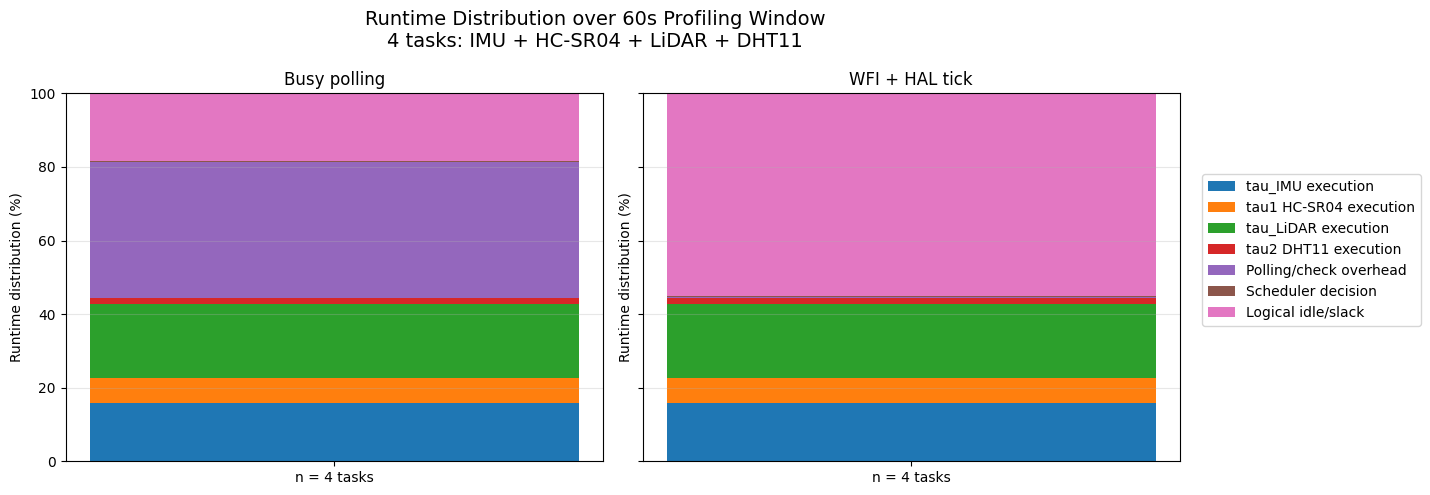


=== Busy polling: runtime distribution ===
tau_IMU execution: 15.8435%
tau1 HC-SR04 execution: 6.8510%
tau_LiDAR execution: 20.0090%
tau2 DHT11 execution: 1.7148%
Polling/check overhead: 36.9388%
Scheduler decision: 0.2690%
Logical idle/slack: 18.3619%
sum: 99.9881%

=== WFI + HAL tick: runtime distribution ===
tau_IMU execution: 15.8233%
tau1 HC-SR04 execution: 6.8640%
tau_LiDAR execution: 20.0090%
tau2 DHT11 execution: 1.6983%
Polling/check overhead: 0.3622%
Scheduler decision: 0.1379%
Logical idle/slack: 55.0927%
sum: 99.9874%

=== Busy polling: deadline / timing quality ===
tau_IMU execution: runs=9412, misses=817, skipped=2588, total_failures=3405, avg_response=2539 us, max_response=57948 us
tau1 HC-SR04 execution: runs=600, misses=0, skipped=0, total_failures=0, avg_response=19128 us, max_response=63846 us
tau_LiDAR execution: runs=600, misses=0, skipped=0, total_failures=0, avg_response=24177 us, max_response=27973 us
tau2 DHT11 execution: runs=30, misses=0, skipped=0, total_fa

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

profile_window_us = 60_000_000

# -----------------------------
# Data: 4-task run
# Order: IMU -> tau1 HC-SR04 -> tau_LiDAR -> tau2 DHT11
# -----------------------------
runs = {
    "Busy polling": {
        "tasks": {
            "tau_IMU execution": {
                "runs": 9412,
                "avg_exec_us": 1010,
                "misses": 817,
                "skipped": 2588,
                "total_failures": 3405,
                "avg_response_us": 2539,
                "max_response_us": 57948,
            },
            "tau1 HC-SR04 execution": {
                "runs": 600,
                "avg_exec_us": 6851,
                "misses": 0,
                "skipped": 0,
                "total_failures": 0,
                "avg_response_us": 19128,
                "max_response_us": 63846,
            },
            "tau_LiDAR execution": {
                "runs": 600,
                "avg_exec_us": 20009,
                "misses": 0,
                "skipped": 0,
                "total_failures": 0,
                "avg_response_us": 24177,
                "max_response_us": 27973,
            },
            "tau2 DHT11 execution": {
                "runs": 30,
                "avg_exec_us": 34297,
                "misses": 0,
                "skipped": 0,
                "total_failures": 0,
                "avg_response_us": 60986,
                "max_response_us": 63889,
            },
        },

        "polling_check_percent": 37.2078,
        "scheduler_event_percent": 0.2690,
        "logical_idle_percent": 18.3619,
    },

    "WFI + HAL tick": {
        "tasks": {
            "tau_IMU execution": {
                "runs": 9400,
                "avg_exec_us": 1010,
                "misses": 599,
                "skipped": 2600,
                "total_failures": 3199,
                "avg_response_us": 2570,
                "max_response_us": 59000,
            },
            "tau1 HC-SR04 execution": {
                "runs": 600,
                "avg_exec_us": 6864,
                "misses": 0,
                "skipped": 0,
                "total_failures": 0,
                "avg_response_us": 7000,
                "max_response_us": 7000,
            },
            "tau_LiDAR execution": {
                "runs": 600,
                "avg_exec_us": 20009,
                "misses": 0,
                "skipped": 0,
                "total_failures": 0,
                "avg_response_us": 27000,
                "max_response_us": 27000,
            },
            "tau2 DHT11 execution": {
                "runs": 30,
                "avg_exec_us": 33965,
                "misses": 0,
                "skipped": 0,
                "total_failures": 0,
                "avg_response_us": 61033,
                "max_response_us": 62000,
            },
        },

        "polling_check_percent": 0.5001,
        "scheduler_event_percent": 0.1379,
        "logical_idle_percent": 55.0927,
    },
}

component_names = [
    "tau_IMU execution",
    "tau1 HC-SR04 execution",
    "tau_LiDAR execution",
    "tau2 DHT11 execution",
    "Polling/check overhead",
    "Scheduler decision",
    "Logical idle/slack",
]

# -----------------------------
# Prepare calculated data
# -----------------------------
calculated = {}

for run_name, data in runs.items():
    values = {}

    for task_name, task_data in data["tasks"].items():
        values[task_name] = (
            task_data["runs"] * task_data["avg_exec_us"]
        ) / profile_window_us * 100

    # Avoid double-counting:
    # scheduler_event is already included inside polling_check.
    polling_only_percent = (
        data["polling_check_percent"] - data["scheduler_event_percent"]
    )

    values["Polling/check overhead"] = polling_only_percent
    values["Scheduler decision"] = data["scheduler_event_percent"]
    values["Logical idle/slack"] = data["logical_idle_percent"]

    calculated[run_name] = values

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, (run_name, values_dict) in zip(axes, calculated.items()):
    bottom = 0

    for component in component_names:
        value = values_dict[component]

        ax.bar(
            ["n = 4 tasks"],
            [value],
            bottom=bottom,
            label=component
        )

        bottom += value

    ax.set_title(run_name)
    ax.set_ylim(0, 100)
    ax.set_ylabel("Runtime distribution (%)")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(
    "Runtime Distribution over 60s Profiling Window\n"
    "4 tasks: IMU + HC-SR04 + LiDAR + DHT11",
    fontsize=14
)

# One shared legend for both plots
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.0, 0.5)
)

plt.tight_layout()
plt.show()

# -----------------------------
# Print calculated runtime values
# -----------------------------
for run_name, values in calculated.items():
    print(f"\n=== {run_name}: runtime distribution ===")
    total = 0

    for component, value in values.items():
        print(f"{component}: {value:.4f}%")
        total += value

    print(f"sum: {total:.4f}%")

# -----------------------------
# Print timing quality summary
# -----------------------------
for run_name, data in runs.items():
    print(f"\n=== {run_name}: deadline / timing quality ===")

    total_misses = 0
    total_skipped = 0
    total_failures = 0

    for task_name, task_data in data["tasks"].items():
        print(
            f"{task_name}: "
            f"runs={task_data['runs']}, "
            f"misses={task_data['misses']}, "
            f"skipped={task_data['skipped']}, "
            f"total_failures={task_data['total_failures']}, "
            f"avg_response={task_data['avg_response_us']} us, "
            f"max_response={task_data['max_response_us']} us"
        )

        total_misses += task_data["misses"]
        total_skipped += task_data["skipped"]
        total_failures += task_data["total_failures"]

    print(
        f"TOTAL: "
        f"misses={total_misses}, "
        f"skipped={total_skipped}, "
        f"total_failures={total_failures}"
    )

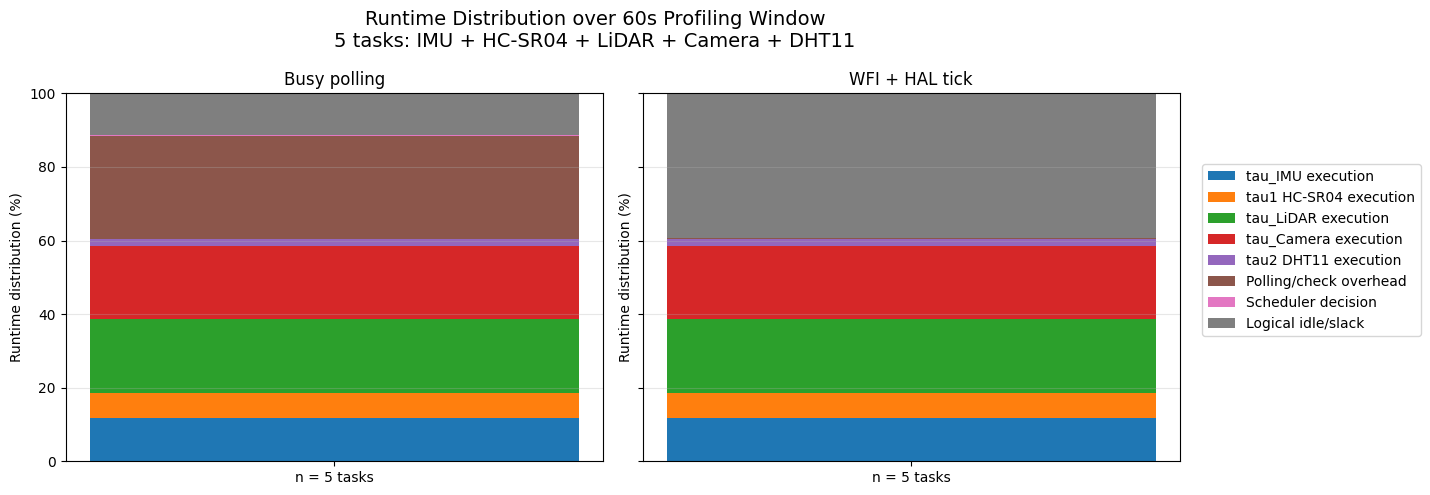


=== Busy polling: runtime distribution ===
tau_IMU execution: 11.7985%
tau1 HC-SR04 execution: 6.7478%
tau_LiDAR execution: 20.0100%
tau_Camera execution: 20.0050%
tau2 DHT11 execution: 1.7357%
Polling/check overhead: 27.9882%
Scheduler decision: 0.2569%
Logical idle/slack: 11.4530%
sum: 99.9950%

=== WFI + HAL tick: runtime distribution ===
tau_IMU execution: 11.7463%
tau1 HC-SR04 execution: 6.8530%
tau_LiDAR execution: 20.0100%
tau_Camera execution: 20.0050%
tau2 DHT11 execution: 1.7028%
Polling/check overhead: 0.2913%
Scheduler decision: 0.1160%
Logical idle/slack: 39.2648%
sum: 99.9892%

=== Busy polling: deadline / timing quality ===
tau_IMU execution: runs=7009, misses=812, skipped=4991, total_failures=5803, avg_response=5841 us, max_response=99000 us
tau1 HC-SR04 execution: runs=592, misses=8, skipped=8, total_failures=16, avg_response=35000 us, max_response=100000 us
tau_LiDAR execution: runs=600, misses=0, skipped=0, total_failures=0, avg_response=57000 us, max_response=61000

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

profile_window_us = 60_000_000

# -----------------------------
# Data: 5-task run
# Order: IMU -> tau1 HC-SR04 -> tau_LiDAR -> tau_Camera -> tau2 DHT11
# -----------------------------
runs = {
    "Busy polling": {
        "tasks": {
            "tau_IMU execution": {
                "runs": 7009,
                "avg_exec_us": 1010,
                "misses": 812,
                "skipped": 4991,
                "total_failures": 5803,
                "avg_response_us": 5841,
                "max_response_us": 99000,
            },
            "tau1 HC-SR04 execution": {
                "runs": 592,
                "avg_exec_us": 6839,
                "misses": 8,
                "skipped": 8,
                "total_failures": 16,
                "avg_response_us": 35000,
                "max_response_us": 100000,
            },
            "tau_LiDAR execution": {
                "runs": 600,
                "avg_exec_us": 20010,
                "misses": 0,
                "skipped": 0,
                "total_failures": 0,
                "avg_response_us": 57000,
                "max_response_us": 61000,
            },
            "tau_Camera execution": {
                "runs": 300,
                "avg_exec_us": 40010,
                "misses": 0,
                "skipped": 0,
                "total_failures": 0,
                "avg_response_us": 97000,
                "max_response_us": 101000,
            },
            "tau2 DHT11 execution": {
                "runs": 30,
                "avg_exec_us": 34713,
                "misses": 0,
                "skipped": 0,
                "total_failures": 0,
                "avg_response_us": 130000,
                "max_response_us": 136000,
            },
        },

        "polling_check_percent": 28.2451,
        "scheduler_event_percent": 0.2569,
        "logical_idle_percent": 11.4530,
    },

    "WFI + HAL tick": {
        "tasks": {
            "tau_IMU execution": {
                "runs": 6978,
                "avg_exec_us": 1010,
                "misses": 599,
                "skipped": 5022,
                "total_failures": 5621,
                "avg_response_us": 5878,
                "max_response_us": 99000,
            },
            "tau1 HC-SR04 execution": {
                "runs": 600,
                "avg_exec_us": 6853,
                "misses": 0,
                "skipped": 0,
                "total_failures": 0,
                "avg_response_us": 7000,
                "max_response_us": 7000,
            },
            "tau_LiDAR execution": {
                "runs": 600,
                "avg_exec_us": 20010,
                "misses": 0,
                "skipped": 0,
                "total_failures": 0,
                "avg_response_us": 27000,
                "max_response_us": 27000,
            },
            "tau_Camera execution": {
                "runs": 300,
                "avg_exec_us": 40010,
                "misses": 0,
                "skipped": 0,
                "total_failures": 0,
                "avg_response_us": 67000,
                "max_response_us": 67000,
            },
            "tau2 DHT11 execution": {
                "runs": 30,
                "avg_exec_us": 34057,
                "misses": 0,
                "skipped": 0,
                "total_failures": 0,
                "avg_response_us": 101000,
                "max_response_us": 101000,
            },
        },

        "polling_check_percent": 0.4073,
        "scheduler_event_percent": 0.1160,
        "logical_idle_percent": 39.2648,
    },
}

component_names = [
    "tau_IMU execution",
    "tau1 HC-SR04 execution",
    "tau_LiDAR execution",
    "tau_Camera execution",
    "tau2 DHT11 execution",
    "Polling/check overhead",
    "Scheduler decision",
    "Logical idle/slack",
]

# -----------------------------
# Prepare calculated data
# -----------------------------
calculated = {}

for run_name, data in runs.items():
    values = {}

    for task_name, task_data in data["tasks"].items():
        values[task_name] = (
            task_data["runs"] * task_data["avg_exec_us"]
        ) / profile_window_us * 100

    # Avoid double-counting:
    # scheduler_event is already included inside polling_check.
    polling_only_percent = (
        data["polling_check_percent"] - data["scheduler_event_percent"]
    )

    values["Polling/check overhead"] = polling_only_percent
    values["Scheduler decision"] = data["scheduler_event_percent"]
    values["Logical idle/slack"] = data["logical_idle_percent"]

    calculated[run_name] = values

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, (run_name, values_dict) in zip(axes, calculated.items()):
    bottom = 0

    for component in component_names:
        value = values_dict[component]

        ax.bar(
            ["n = 5 tasks"],
            [value],
            bottom=bottom,
            label=component
        )

        bottom += value

    ax.set_title(run_name)
    ax.set_ylim(0, 100)
    ax.set_ylabel("Runtime distribution (%)")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(
    "Runtime Distribution over 60s Profiling Window\n"
    "5 tasks: IMU + HC-SR04 + LiDAR + Camera + DHT11",
    fontsize=14
)

# One shared legend for both plots
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.0, 0.5)
)

plt.tight_layout()
plt.show()

# -----------------------------
# Print calculated runtime values
# -----------------------------
for run_name, values in calculated.items():
    print(f"\n=== {run_name}: runtime distribution ===")
    total = 0

    for component, value in values.items():
        print(f"{component}: {value:.4f}%")
        total += value

    print(f"sum: {total:.4f}%")

# -----------------------------
# Print timing quality summary
# -----------------------------
for run_name, data in runs.items():
    print(f"\n=== {run_name}: deadline / timing quality ===")

    total_misses = 0
    total_skipped = 0
    total_failures = 0

    for task_name, task_data in data["tasks"].items():
        print(
            f"{task_name}: "
            f"runs={task_data['runs']}, "
            f"misses={task_data['misses']}, "
            f"skipped={task_data['skipped']}, "
            f"total_failures={task_data['total_failures']}, "
            f"avg_response={task_data['avg_response_us']} us, "
            f"max_response={task_data['max_response_us']} us"
        )

        total_misses += task_data["misses"]
        total_skipped += task_data["skipped"]
        total_failures += task_data["total_failures"]

    print(
        f"TOTAL: "
        f"misses={total_misses}, "
        f"skipped={total_skipped}, "
        f"total_failures={total_failures}"
    )

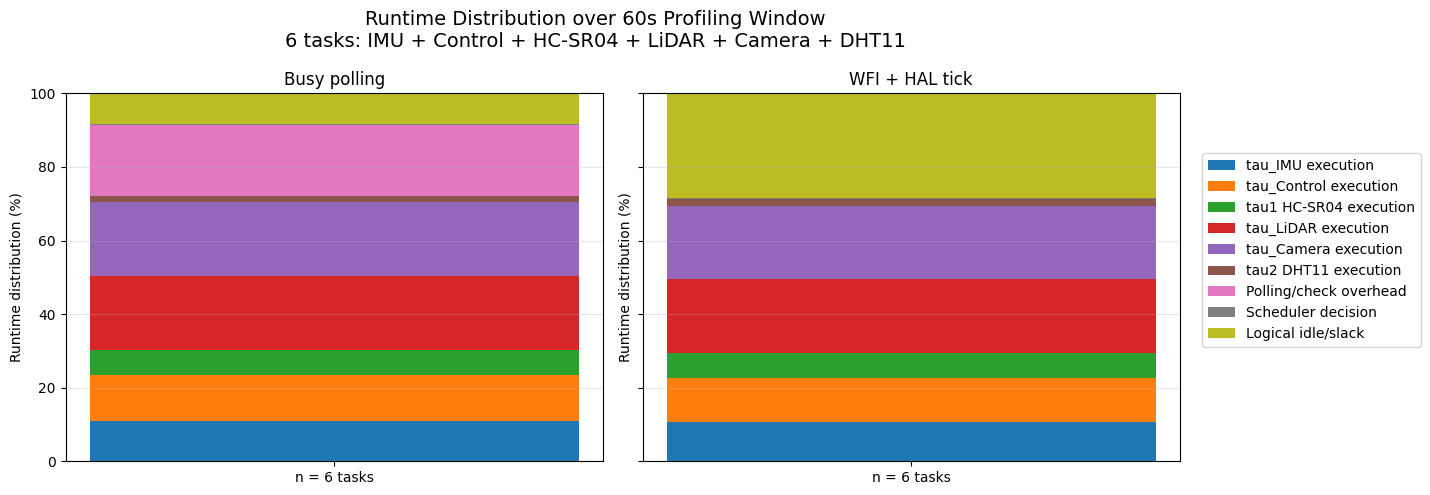


=== Busy polling: runtime distribution ===
tau_IMU execution: 11.0595%
tau_Control execution: 12.4787%
tau1 HC-SR04 execution: 6.8396%
tau_LiDAR execution: 20.0090%
tau_Camera execution: 20.0050%
tau2 DHT11 execution: 1.7433%
Polling/check overhead: 19.2957%
Scheduler decision: 0.3328%
Logical idle/slack: 8.2230%
sum: 99.9866%

=== WFI + HAL tick: runtime distribution ===
tau_IMU execution: 10.7902%
tau_Control execution: 11.7945%
tau1 HC-SR04 execution: 6.8420%
tau_LiDAR execution: 20.0090%
tau_Camera execution: 20.0050%
tau2 DHT11 execution: 1.7254%
Polling/check overhead: 0.2412%
Scheduler decision: 0.1334%
Logical idle/slack: 28.4488%
sum: 99.9894%

=== Busy polling: deadline / timing quality ===
tau_IMU execution: runs=6570, misses=816, skipped=5430, total_failures=6246, avg_response=5747 us, max_response=101002 us
tau_Control execution: runs=3725, misses=628, skipped=2275, total_failures=2903, avg_response=9218 us, max_response=98051 us
tau1 HC-SR04 execution: runs=599, misses=1

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

profile_window_us = 60_000_000

# -----------------------------
# Data: 6-task run
# Order: IMU -> Control -> tau1 HC-SR04 -> tau_LiDAR -> tau_Camera -> tau2 DHT11
# -----------------------------
runs = {
    "Busy polling": {
        "tasks": {
            "tau_IMU execution": {
                "runs": 6570,
                "avg_exec_us": 1010,
                "misses": 816,
                "skipped": 5430,
                "total_failures": 6246,
                "avg_response_us": 5747,
                "max_response_us": 101002,
            },
            "tau_Control execution": {
                "runs": 3725,
                "avg_exec_us": 2010,
                "misses": 628,
                "skipped": 2275,
                "total_failures": 2903,
                "avg_response_us": 9218,
                "max_response_us": 98051,
            },
            "tau1 HC-SR04 execution": {
                "runs": 599,
                "avg_exec_us": 6851,
                "misses": 1,
                "skipped": 1,
                "total_failures": 2,
                "avg_response_us": 26353,
                "max_response_us": 107929,
            },
            "tau_LiDAR execution": {
                "runs": 600,
                "avg_exec_us": 20009,
                "misses": 0,
                "skipped": 0,
                "total_failures": 0,
                "avg_response_us": 29255,
                "max_response_us": 72086,
            },
            "tau_Camera execution": {
                "runs": 300,
                "avg_exec_us": 40010,
                "misses": 0,
                "skipped": 0,
                "total_failures": 0,
                "avg_response_us": 65700,
                "max_response_us": 70048,
            },
            "tau2 DHT11 execution": {
                "runs": 30,
                "avg_exec_us": 34866,
                "misses": 0,
                "skipped": 0,
                "total_failures": 0,
                "avg_response_us": 105729,
                "max_response_us": 107934,
            },
        },

        "polling_check_percent": 19.6285,
        "scheduler_event_percent": 0.3328,
        "logical_idle_percent": 8.2230,
    },

    "WFI + HAL tick": {
        "tasks": {
            "tau_IMU execution": {
                "runs": 6410,
                "avg_exec_us": 1010,
                "misses": 599,
                "skipped": 5590,
                "total_failures": 6189,
                "avg_response_us": 5357,
                "max_response_us": 101000,
            },
            "tau_Control execution": {
                "runs": 3519,
                "avg_exec_us": 2011,
                "misses": 599,
                "skipped": 2481,
                "total_failures": 3080,
                "avg_response_us": 10128,
                "max_response_us": 98000,
            },
            "tau1 HC-SR04 execution": {
                "runs": 600,
                "avg_exec_us": 6842,
                "misses": 0,
                "skipped": 0,
                "total_failures": 0,
                "avg_response_us": 9220,
                "max_response_us": 14000,
            },
            "tau_LiDAR execution": {
                "runs": 600,
                "avg_exec_us": 20009,
                "misses": 0,
                "skipped": 0,
                "total_failures": 0,
                "avg_response_us": 29225,
                "max_response_us": 35000,
            },
            "tau_Camera execution": {
                "runs": 300,
                "avg_exec_us": 40010,
                "misses": 0,
                "skipped": 0,
                "total_failures": 0,
                "avg_response_us": 69013,
                "max_response_us": 70000,
            },
            "tau2 DHT11 execution": {
                "runs": 30,
                "avg_exec_us": 34507,
                "misses": 0,
                "skipped": 0,
                "total_failures": 0,
                "avg_response_us": 103566,
                "max_response_us": 104000,
            },
        },

        "polling_check_percent": 0.3746,
        "scheduler_event_percent": 0.1334,
        "logical_idle_percent": 28.4488,
    },
}

component_names = [
    "tau_IMU execution",
    "tau_Control execution",
    "tau1 HC-SR04 execution",
    "tau_LiDAR execution",
    "tau_Camera execution",
    "tau2 DHT11 execution",
    "Polling/check overhead",
    "Scheduler decision",
    "Logical idle/slack",
]

# -----------------------------
# Prepare calculated data
# -----------------------------
calculated = {}

for run_name, data in runs.items():
    values = {}

    for task_name, task_data in data["tasks"].items():
        values[task_name] = (
            task_data["runs"] * task_data["avg_exec_us"]
        ) / profile_window_us * 100

    # Avoid double-counting:
    # scheduler_event is already included inside polling_check.
    polling_only_percent = (
        data["polling_check_percent"] - data["scheduler_event_percent"]
    )

    values["Polling/check overhead"] = polling_only_percent
    values["Scheduler decision"] = data["scheduler_event_percent"]
    values["Logical idle/slack"] = data["logical_idle_percent"]

    calculated[run_name] = values

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for ax, (run_name, values_dict) in zip(axes, calculated.items()):
    bottom = 0

    for component in component_names:
        value = values_dict[component]

        ax.bar(
            ["n = 6 tasks"],
            [value],
            bottom=bottom,
            label=component
        )

        bottom += value

    ax.set_title(run_name)
    ax.set_ylim(0, 100)
    ax.set_ylabel("Runtime distribution (%)")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle(
    "Runtime Distribution over 60s Profiling Window\n"
    "6 tasks: IMU + Control + HC-SR04 + LiDAR + Camera + DHT11",
    fontsize=14
)

# One shared legend for both plots
handles, labels = axes[0].get_legend_handles_labels()

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(1.0, 0.5)
)

plt.tight_layout()
plt.show()

# -----------------------------
# Print calculated runtime values
# -----------------------------
for run_name, values in calculated.items():
    print(f"\n=== {run_name}: runtime distribution ===")
    total = 0

    for component, value in values.items():
        print(f"{component}: {value:.4f}%")
        total += value

    print(f"sum: {total:.4f}%")

# -----------------------------
# Print timing quality summary
# -----------------------------
for run_name, data in runs.items():
    print(f"\n=== {run_name}: deadline / timing quality ===")

    total_misses = 0
    total_skipped = 0
    total_failures = 0

    for task_name, task_data in data["tasks"].items():
        print(
            f"{task_name}: "
            f"runs={task_data['runs']}, "
            f"misses={task_data['misses']}, "
            f"skipped={task_data['skipped']}, "
            f"total_failures={task_data['total_failures']}, "
            f"avg_response={task_data['avg_response_us']} us, "
            f"max_response={task_data['max_response_us']} us"
        )

        total_misses += task_data["misses"]
        total_skipped += task_data["skipped"]
        total_failures += task_data["total_failures"]

    print(
        f"TOTAL: "
        f"misses={total_misses}, "
        f"skipped={total_skipped}, "
        f"total_failures={total_failures}"
    )

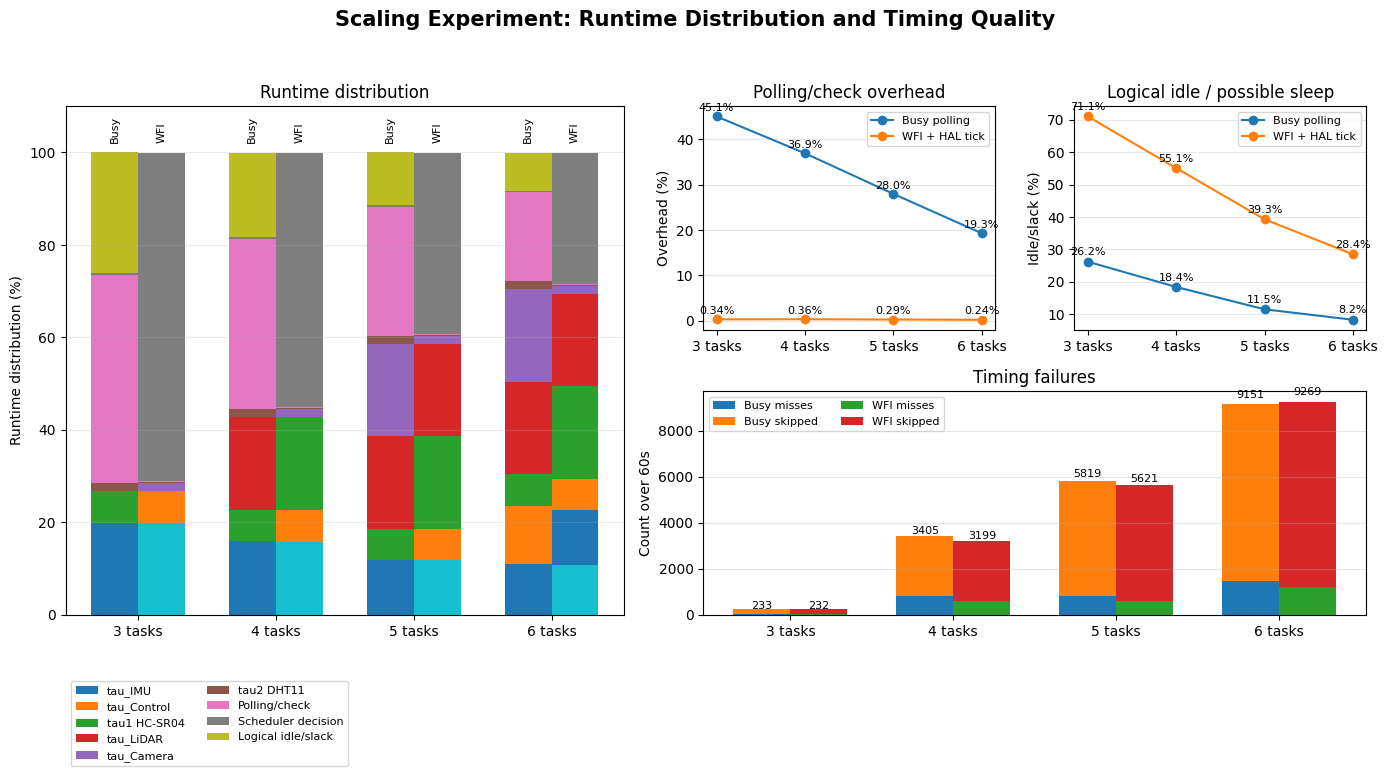


=== Compact summary ===
workload           mode  task_load  polling_check  scheduler_decision  logical_idle  misses  skipped  total_failures
 3 tasks   Busy polling    28.4812        45.0676              0.2667       26.1774      31      202             233
 3 tasks WFI + HAL tick    28.4570         0.3352              0.1240       71.0721      29      203             232
 4 tasks   Busy polling    44.4183        36.9388              0.2690       18.3619     817     2588            3405
 4 tasks WFI + HAL tick    44.3946         0.3622              0.1379       55.0927     599     2600            3199
 5 tasks   Busy polling    60.2970        27.9882              0.2569       11.4530     820     4999            5819
 5 tasks WFI + HAL tick    60.3171         0.2913              0.1160       39.2648     599     5022            5621
 6 tasks   Busy polling    72.1351        19.2957              0.3328        8.2230    1445     7706            9151
 6 tasks WFI + HAL tick    71.1661     

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ============================================================
# Data
# ============================================================

workloads = {
    "3 tasks": {
        "Busy polling": {
            "runtime": {
                "tau_IMU": 19.8600,
                "tau1 HC-SR04": 6.8935,
                "tau2 DHT11": 1.7277,
                "Polling/check": 45.0676,
                "Scheduler decision": 0.2667,
                "Logical idle/slack": 26.1774,
            },
            "timing": {
                "misses": 31,
                "skipped": 202,
                "total_failures": 233,
            },
        },
        "WFI + HAL tick": {
            "runtime": {
                "tau_IMU": 19.8583,
                "tau1 HC-SR04": 6.9000,
                "tau2 DHT11": 1.6987,
                "Polling/check": 0.3352,
                "Scheduler decision": 0.1240,
                "Logical idle/slack": 71.0721,
            },
            "timing": {
                "misses": 29,
                "skipped": 203,
                "total_failures": 232,
            },
        },
    },

    "4 tasks": {
        "Busy polling": {
            "runtime": {
                "tau_IMU": 15.8435,
                "tau1 HC-SR04": 6.8510,
                "tau_LiDAR": 20.0090,
                "tau2 DHT11": 1.7148,
                "Polling/check": 36.9388,
                "Scheduler decision": 0.2690,
                "Logical idle/slack": 18.3619,
            },
            "timing": {
                "misses": 817,
                "skipped": 2588,
                "total_failures": 3405,
            },
        },
        "WFI + HAL tick": {
            "runtime": {
                "tau_IMU": 15.8233,
                "tau1 HC-SR04": 6.8640,
                "tau_LiDAR": 20.0090,
                "tau2 DHT11": 1.6983,
                "Polling/check": 0.3622,
                "Scheduler decision": 0.1379,
                "Logical idle/slack": 55.0927,
            },
            "timing": {
                "misses": 599,
                "skipped": 2600,
                "total_failures": 3199,
            },
        },
    },

    "5 tasks": {
        "Busy polling": {
            "runtime": {
                "tau_IMU": 11.7985,
                "tau1 HC-SR04": 6.7478,
                "tau_LiDAR": 20.0100,
                "tau_Camera": 20.0050,
                "tau2 DHT11": 1.7357,
                "Polling/check": 27.9882,
                "Scheduler decision": 0.2569,
                "Logical idle/slack": 11.4530,
            },
            "timing": {
                "misses": 820,
                "skipped": 4999,
                "total_failures": 5819,
            },
        },
        "WFI + HAL tick": {
            "runtime": {
                "tau_IMU": 11.7463,
                "tau1 HC-SR04": 6.8530,
                "tau_LiDAR": 20.0100,
                "tau_Camera": 20.0050,
                "tau2 DHT11": 1.7028,
                "Polling/check": 0.2913,
                "Scheduler decision": 0.1160,
                "Logical idle/slack": 39.2648,
            },
            "timing": {
                "misses": 599,
                "skipped": 5022,
                "total_failures": 5621,
            },
        },
    },

    "6 tasks": {
        "Busy polling": {
            "runtime": {
                "tau_IMU": 11.0595,
                "tau_Control": 12.4787,
                "tau1 HC-SR04": 6.8396,
                "tau_LiDAR": 20.0090,
                "tau_Camera": 20.0050,
                "tau2 DHT11": 1.7433,
                "Polling/check": 19.2957,
                "Scheduler decision": 0.3328,
                "Logical idle/slack": 8.2230,
            },
            "timing": {
                "misses": 1445,
                "skipped": 7706,
                "total_failures": 9151,
            },
        },
        "WFI + HAL tick": {
            "runtime": {
                "tau_IMU": 10.7902,
                "tau_Control": 11.7945,
                "tau1 HC-SR04": 6.8420,
                "tau_LiDAR": 20.0090,
                "tau_Camera": 20.0050,
                "tau2 DHT11": 1.7254,
                "Polling/check": 0.2412,
                "Scheduler decision": 0.1334,
                "Logical idle/slack": 28.4488,
            },
            "timing": {
                "misses": 1198,
                "skipped": 8071,
                "total_failures": 9269,
            },
        },
    },
}

workload_names = ["3 tasks", "4 tasks", "5 tasks", "6 tasks"]
modes = ["Busy polling", "WFI + HAL tick"]

task_components = [
    "tau_IMU",
    "tau_Control",
    "tau1 HC-SR04",
    "tau_LiDAR",
    "tau_Camera",
    "tau2 DHT11",
]

system_components = [
    "Polling/check",
    "Scheduler decision",
    "Logical idle/slack",
]

all_components = task_components + system_components


# ============================================================
# Build summary dataframe
# ============================================================

rows = []

for workload in workload_names:
    for mode in modes:
        runtime = workloads[workload][mode]["runtime"]
        timing = workloads[workload][mode]["timing"]

        task_load = sum(runtime.get(c, 0) for c in task_components)

        rows.append({
            "workload": workload,
            "mode": mode,
            "task_load": task_load,
            "polling_check": runtime["Polling/check"],
            "scheduler_decision": runtime["Scheduler decision"],
            "logical_idle": runtime["Logical idle/slack"],
            "misses": timing["misses"],
            "skipped": timing["skipped"],
            "total_failures": timing["total_failures"],
        })

df = pd.DataFrame(rows)


# ============================================================
# Compact dashboard figure
# ============================================================

fig = plt.figure(figsize=(14, 8))

gs = fig.add_gridspec(
    2,
    3,
    width_ratios=[2.2, 1.15, 1.15],
    height_ratios=[1, 1],
)

ax_runtime = fig.add_subplot(gs[:, 0])
ax_overhead = fig.add_subplot(gs[0, 1])
ax_idle = fig.add_subplot(gs[0, 2])
ax_failures = fig.add_subplot(gs[1, 1:])
fig.suptitle(
    "Scaling Experiment: Runtime Distribution and Timing Quality",
    fontsize=15,
    fontweight="bold",
)


# ============================================================
# 1) Runtime distribution: compact stacked bars
# ============================================================

x = np.arange(len(workload_names))
bar_width = 0.34

positions = {
    "Busy polling": x - bar_width / 2,
    "WFI + HAL tick": x + bar_width / 2,
}

for mode in modes:
    bottom = np.zeros(len(workload_names))

    for component in all_components:
        values = [
            workloads[w][mode]["runtime"].get(component, 0)
            for w in workload_names
        ]

        bars = ax_runtime.bar(
            positions[mode],
            values,
            bar_width,
            bottom=bottom,
            label=component if mode == "Busy polling" else None,
        )

        bottom += np.array(values)

    for i, total in enumerate(bottom):
        ax_runtime.text(
            positions[mode][i],
            102,
            "Busy" if mode == "Busy polling" else "WFI",
            ha="center",
            va="bottom",
            fontsize=8,
            rotation=90,
        )

ax_runtime.set_title("Runtime distribution")
ax_runtime.set_ylabel("Runtime distribution (%)")
ax_runtime.set_xticks(x)
ax_runtime.set_xticklabels(workload_names)
ax_runtime.set_ylim(0, 110)
ax_runtime.grid(axis="y", alpha=0.25)

ax_runtime.legend(
    loc="upper left",
    bbox_to_anchor=(0.0, -0.12),
    ncol=2,
    fontsize=8,
)


# ============================================================
# Helper for trend lines
# ============================================================

def get_metric(mode, metric):
    return [
        df[(df["workload"] == w) & (df["mode"] == mode)][metric].values[0]
        for w in workload_names
    ]


# ============================================================
# 2) Polling/check overhead trend
# ============================================================

busy_polling = get_metric("Busy polling", "polling_check")
wfi_polling = get_metric("WFI + HAL tick", "polling_check")

ax_overhead.plot(workload_names, busy_polling, marker="o", label="Busy polling")
ax_overhead.plot(workload_names, wfi_polling, marker="o", label="WFI + HAL tick")

ax_overhead.set_title("Polling/check overhead")
ax_overhead.set_ylabel("Overhead (%)")
ax_overhead.grid(axis="y", alpha=0.3)
ax_overhead.legend(fontsize=8)

for i, value in enumerate(busy_polling):
    ax_overhead.text(i, value + 1.2, f"{value:.1f}%", ha="center", fontsize=8)

for i, value in enumerate(wfi_polling):
    ax_overhead.text(i, value + 1.2, f"{value:.2f}%", ha="center", fontsize=8)


# ============================================================
# 3) Logical idle/slack trend
# ============================================================

busy_idle = get_metric("Busy polling", "logical_idle")
wfi_idle = get_metric("WFI + HAL tick", "logical_idle")

ax_idle.plot(workload_names, busy_idle, marker="o", label="Busy polling")
ax_idle.plot(workload_names, wfi_idle, marker="o", label="WFI + HAL tick")

ax_idle.set_title("Logical idle / possible sleep")
ax_idle.set_ylabel("Idle/slack (%)")
ax_idle.grid(axis="y", alpha=0.3)
ax_idle.legend(fontsize=8)

for i, value in enumerate(busy_idle):
    ax_idle.text(i, value + 2, f"{value:.1f}%", ha="center", fontsize=8)

for i, value in enumerate(wfi_idle):
    ax_idle.text(i, value + 2, f"{value:.1f}%", ha="center", fontsize=8)


# ============================================================
# 4) Timing failures: misses + skipped releases
# ============================================================

x_fail = np.arange(len(workload_names))
width = 0.35

busy_misses = get_metric("Busy polling", "misses")
busy_skipped = get_metric("Busy polling", "skipped")

wfi_misses = get_metric("WFI + HAL tick", "misses")
wfi_skipped = get_metric("WFI + HAL tick", "skipped")

ax_failures.bar(
    x_fail - width / 2,
    busy_misses,
    width,
    label="Busy misses",
)

ax_failures.bar(
    x_fail - width / 2,
    busy_skipped,
    width,
    bottom=busy_misses,
    label="Busy skipped",
)

ax_failures.bar(
    x_fail + width / 2,
    wfi_misses,
    width,
    label="WFI misses",
)

ax_failures.bar(
    x_fail + width / 2,
    wfi_skipped,
    width,
    bottom=wfi_misses,
    label="WFI skipped",
)

ax_failures.set_title("Timing failures")
ax_failures.set_ylabel("Count over 60s")
ax_failures.set_xticks(x_fail)
ax_failures.set_xticklabels(workload_names)
ax_failures.grid(axis="y", alpha=0.3)
ax_failures.legend(ncol=2, fontsize=8)

for i in range(len(workload_names)):
    busy_total = busy_misses[i] + busy_skipped[i]
    wfi_total = wfi_misses[i] + wfi_skipped[i]

    ax_failures.text(
        i - width / 2,
        busy_total + max(busy_total, wfi_total) * 0.03,
        str(busy_total),
        ha="center",
        fontsize=8,
    )

    ax_failures.text(
        i + width / 2,
        wfi_total + max(busy_total, wfi_total) * 0.03,
        str(wfi_total),
        ha="center",
        fontsize=8,
    )


# ============================================================
# Final layout
# ============================================================

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig("compact_runtime_timing_dashboard.png", dpi=300, bbox_inches="tight")
plt.show()


# ============================================================
# Print table for checking
# ============================================================

print("\n=== Compact summary ===")
print(df.to_string(index=False))

τ1 HC-SR04
  samples: 600
  min:     5.220 ms
  Q1:      10.995 ms
  median:  11.017 ms
  avg:     11.013 ms
  Q3:      11.041 ms
  max:     11.440 ms

τ2 DHT11
  samples: 30
  min:     34.660 ms
  Q1:      34.712 ms
  median:  34.733 ms
  avg:     34.779 ms
  Q3:      34.869 ms
  max:     34.917 ms



/tmp/ipykernel_1715/3022595052.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(
/tmp/ipykernel_1715/3022595052.py:96: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = ax.boxplot(


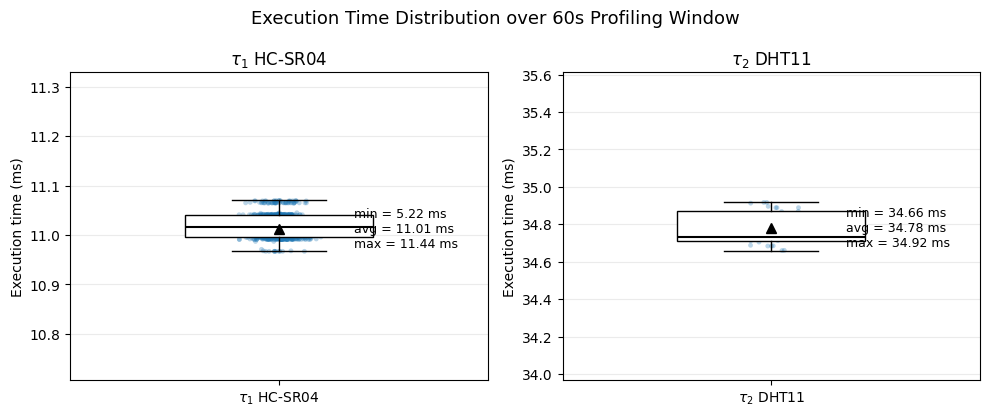

In [ ]:
import re
import numpy as np
import matplotlib.pyplot as plt

# Paste the full UART log here
log_text = """

TAU1_EXEC_SAMPLES_US:
11020,10968,10991,10996,5220,11021,11017,11021,11022,11021,10996,11021,11021,10992,10996,11020,11021,10992,10995,11021,
10995,10996,10996,11021,10991,10995,11017,10995,11021,10991,10991,10995,11017,11021,10995,10995,11021,10996,10996,10996,
11021,11020,11021,11021,10995,11020,11045,10995,10995,11021,11021,11021,10995,11021,11022,11021,11020,11044,11044,11020,
11021,11020,11021,11021,11021,11020,11021,10995,11021,10995,11045,11021,11021,11021,11021,10995,11020,11020,11021,11021,
11017,10995,11021,10971,11020,11020,11020,10996,10995,10995,11021,10995,10995,11020,11017,10995,11021,10995,10995,11021,
10995,11021,11022,10995,11021,10996,11021,10995,10995,11021,11021,11021,11021,11022,10991,10996,10996,10996,11021,11021,
11021,11021,11021,10995,11020,11021,11021,11021,11020,11020,10995,11021,11021,11021,11021,10995,11021,11069,11021,11069,
11021,11020,10995,10995,11020,11021,10995,10996,10995,10995,10995,10995,10996,10996,10995,10995,11020,10995,10995,10996,
10995,10995,10996,10995,10995,11041,10995,10995,10996,10992,10996,10991,10996,11041,10991,10996,10996,11021,10995,10995,
10995,10995,10992,10996,10995,10992,10995,10996,10995,10991,10996,10992,11021,10991,11070,11069,10992,10991,11041,10992,
10992,10991,11042,10995,10967,11042,11041,11069,11065,11041,10991,11041,11041,11041,11021,11066,11065,11069,10991,10967,
10996,10991,10967,11041,11017,11041,11017,11017,11013,11017,11041,11041,11017,11041,11042,11017,11041,11041,11041,11041,
11041,11016,11017,10987,10991,11017,10991,11013,10987,11017,11041,11017,11041,11041,11041,11042,11012,11040,11041,11041,
11041,11040,11040,11041,11041,11013,11041,11040,11040,11017,11013,11041,11041,11016,11016,10991,11017,11041,10992,11017,
11041,11016,11017,11012,11017,11013,11040,11016,11013,11016,11041,11013,11041,11013,11013,11041,11041,11040,11065,11040,
11013,11017,11040,11016,10995,10967,11041,11040,11016,11016,10967,11041,11017,11040,11040,11016,11016,11041,11069,11065,
11042,11040,10967,10995,11065,10995,11040,10991,11041,11041,11041,11041,11065,11066,11065,11041,11065,11041,11017,11041,
11013,10991,11041,11041,11017,11017,11041,11041,11041,10992,11041,11041,11041,11041,11041,11065,11041,11041,11018,11065,
11041,11064,11064,11040,11040,11068,11068,11040,11066,10992,10995,10991,10991,10991,11017,11065,10991,11065,11017,10991,
11069,10991,11070,10992,11041,11069,10992,11070,11041,11066,11069,11065,11042,11041,11042,11042,10991,11041,10992,11013,
11017,11040,11040,11020,11041,11041,11069,11065,11069,11065,11065,11069,11017,11069,11041,11065,11065,10991,10991,10991,
10992,11066,11065,11065,11065,11017,11363,11066,10992,10992,11017,11017,10967,10996,10967,10991,10991,10991,10995,10995,
10996,10992,11066,10992,10996,10992,10991,10995,10991,10995,10991,11065,11042,11065,11017,11065,11041,11017,11022,10995,
10995,11041,10996,11042,11041,11066,11065,11065,11411,11439,10992,10992,11017,10991,10992,11017,10991,10991,10991,10991,
10991,10995,11021,10992,10992,10992,11041,11021,10995,10991,11021,10992,10996,11021,10991,11021,11021,11021,11021,11021,
10996,10992,10996,10968,11412,11367,11069,11021,11017,10992,11021,10996,10992,10995,10992,11021,10995,10967,10995,10995,
11021,10991,11021,10996,10996,10995,11021,10992,10996,10992,10996,10992,10996,11021,10991,10995,10995,10995,10995,10991,
10967,10995,10995,11020,11020,10992,10992,10996,10992,10992,10992,10992,10991,10992,10992,10995,10995,10995,11041,10996,
11042,11041,11016,11040,10992,10991,11013,11017,11041,11041,11041,11065,11440,10992,11041,11066,11439,11041,11017,11041,
11041,11069,11017,11065,11065,11041,11041,11041,11065,11041,11017,11040,11041,11040,11040,11040,11040,11040,10995,11017


TAU2_EXEC_SAMPLES_US:
34847,34868,34845,34889,34889,34889,34841,34917,34913,34917,34758,34688,34684,34712,34685,34661,34684,34660,34732,34713,
34733,34733,34728,34732,34705,34729,34733,34729,34869,34896
=======================================

"""

def extract_samples(log_text, section_name):
    pattern = rf"{section_name}:\s*(.*?)(?:\n\s*\n|TAU\d_EXEC_SAMPLES_US:|=======================================)"
    match = re.search(pattern, log_text, flags=re.DOTALL)

    if not match:
        raise ValueError(f"Section not found: {section_name}")

    raw = match.group(1)
    values = [int(x) for x in re.findall(r"\d+", raw)]

    return np.array(values, dtype=float)


def print_stats(name, values):
    print(name)
    print(f"  samples: {len(values)}")
    print(f"  min:     {np.min(values):.3f} ms")
    print(f"  Q1:      {np.percentile(values, 25):.3f} ms")
    print(f"  median:  {np.median(values):.3f} ms")
    print(f"  avg:     {np.mean(values):.3f} ms")
    print(f"  Q3:      {np.percentile(values, 75):.3f} ms")
    print(f"  max:     {np.max(values):.3f} ms")
    print()


def plot_two_boxplots_side_by_side(tau1_values, tau2_values, output_name):
    rng = np.random.default_rng(1)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2))

    datasets = [
        {
            "values": tau1_values,
            "label": r"$\tau_1$ HC-SR04",
            "title": r"$\tau_1$ HC-SR04",
        },
        {
            "values": tau2_values,
            "label": r"$\tau_2$ DHT11",
            "title": r"$\tau_2$ DHT11",
        }
    ]

    for ax, item in zip(axes, datasets):
        values = item["values"]
        label = item["label"]
        title = item["title"]

        box = ax.boxplot(
            [values],
            labels=[label],
            showmeans=True,
            widths=0.45,
            patch_artist=True,
            meanprops={
                "marker": "^",
                "markerfacecolor": "black",
                "markeredgecolor": "black",
                "markersize": 7
            },
            medianprops={
                "color": "black",
                "linewidth": 1.5
            }
        )

        for patch in box["boxes"]:
            patch.set_facecolor("white")
            patch.set_edgecolor("black")

        for element in ["whiskers", "caps", "fliers"]:
            for line in box[element]:
                line.set_color("black")

        # Real execution samples
        x = rng.normal(1, 0.035, size=len(values))
        ax.scatter(
            x,
            values,
            s=12,
            alpha=0.30,
            edgecolors="none"
        )

        min_v = np.min(values)
        avg_v = np.mean(values)
        max_v = np.max(values)

        text = (
            f"min = {min_v:.2f} ms\n"
            f"avg = {avg_v:.2f} ms\n"
            f"max = {max_v:.2f} ms"
        )

        ax.text(
            1.18,
            avg_v,
            text,
            fontsize=9,
            va="center"
        )

        # Zoom around main distribution
        q1 = np.percentile(values, 25)
        q3 = np.percentile(values, 75)
        iqr = q3 - q1

        y_min = q1 - 3 * iqr
        y_max = q3 + 3 * iqr

        padding = max(0.15, (y_max - y_min) * 0.25)

        ax.set_ylim(y_min - padding, y_max + padding)

        ax.set_title(title)
        ax.set_ylabel("Execution time (ms)")
        ax.grid(axis="y", alpha=0.25)

    fig.suptitle("Execution Time Distribution over 60s Profiling Window", fontsize=13)

    fig.tight_layout()
    fig.savefig(output_name, dpi=300, bbox_inches="tight")
    plt.show()

# Extract samples and convert us -> ms
tau1_ms = extract_samples(log_text, "TAU1_EXEC_SAMPLES_US") / 1000.0
tau2_ms = extract_samples(log_text, "TAU2_EXEC_SAMPLES_US") / 1000.0

print_stats("τ1 HC-SR04", tau1_ms)
print_stats("τ2 DHT11", tau2_ms)

plot_two_boxplots_side_by_side(
    tau1_ms,
    tau2_ms,
    "execution_time_boxplots_side_by_side.png"
)